In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if 'google.colab' in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

# Знакомство с `StatsForecast`: данные и визуализация

`StatsForecast` — библиотека от Nixtla для быстрого прогнозирования **множества рядов
одновременно**. Она отвечает на вопрос, который не решают «академические» библиотеки:
*«у меня 50 000 товаров в 300 магазинах, как построить прогноз для каждого и не ждать
сутки?»*

Ключевое отличие от `statsmodels`: там один вызов = один ряд. Здесь один вызов =
**таблица из тысяч рядов**, а классические модели (ARIMA, ETS, Theta) переписаны на
C/Numba и считаются параллельно.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Как устроена библиотека, из каких пакетов состоит |
| 1 | В каком виде `StatsForecast` хочет получить данные («длинный» формат) и как их проверить |
| 2 | Какие графики библиотека умеет строить сама — и чего в них нет |

🔍 Чего сегодня **не** будет: мы не строим прогнозы и не преобразуем данные.
Сначала — научиться приводить данные к нужному виду и смотреть на них; преобразования
признаков и анализ прогнозов будут на следующих занятиях. Модели упоминаются лишь
затем, чтобы стало понятно, зачем библиотеке именно такой формат данных.


> **Соглашение об оформлении.** Блоки, начинающиеся с 🔍, — это то, на что стоит
> обратить внимание особо: там прячутся типичные ошибки новичков.

---
# 0. Основная концепция библиотеки и её структура

## 0.1. Главная идея: «одна таблица — много рядов»

Представьте, что вам нужен прогноз продаж по 1000 товарам. Наивный подход — цикл:

```python
for товар in товары:            # ← 1000 итераций
    ряд = данные[товар]
    модель = ARIMA(ряд).fit()   # ← каждая обучается на чистом Python
    прогноз[товар] = модель.forecast(12)
```

Это работает, но медленно и неудобно. `StatsForecast` предлагает другое:

```python
sf = StatsForecast(models=[AutoARIMA()], freq='MS')  # 1. ОПИСАНИЕ: какие модели, какой шаг
forecasts = sf.forecast(h=12, df=все_1000_рядов)     # 2. ВЫЗОВ: сразу на всей таблице
```

Цикл никуда не исчез — он просто спрятан внутрь библиотеки и выполняется
скомпилированным кодом, а разные ряды считаются в разных процессах.

🔍 Отсюда вытекает **всё остальное** в этой библиотеке. Если данные — одна таблица со
множеством рядов, то в ней обязательно должен быть столбец «какой это ряд». Это и есть
главное отличие формата данных, к которому мы перейдём в разделе 1.

## 0.2. Три интерфейса вместо одного

В `StatsForecast` есть два способа получить прогноз, и новички часто путаются, какой брать.

| Способ | Код | Что происходит |
|---|---|---|
| **Быстрый** | `sf.forecast(h=12, df=df)` | обучение и прогноз за один вызов, модели не сохраняются |
| **Классический** | `sf.fit(df)` → `sf.predict(h=12)` | обученные модели остаются в объекте `sf` |

По умолчанию используйте `forecast()`: он не хранит обученные модели в памяти, а при
тысячах рядов это принципиально. `fit`/`predict` нужен, когда вы хотите заглянуть
внутрь моделей или прогнозировать много раз без переобучения.

Отдельно стоит `cross_validation()` — правильная схема оценки качества на временных
рядах. Мы вернёмся к ней на занятии про оценку прогнозов.

## 0.3. Структура: одна библиотека — три пакета

Здесь кроется главная сложность навигации. Установив `statsforecast`, вы получаете
**три** пакета, и нужные функции лежат в разных. Это осознанное решение Nixtla:
общий код вынесен наружу, чтобы им пользовались и другие их библиотеки
(`mlforecast` — для градиентного бустинга, `neuralforecast` — для нейросетей).

| Пакет | Что внутри | Примеры |
|---|---|---|
| `statsforecast` | классы моделей и главный класс-оркестратор | `StatsForecast`, `AutoARIMA`, `AutoETS` |
| `utilsforecast` | работа с данными: проверка, пропуски, признаки, **графики** | `plot_series`, `fill_gaps`, `fourier` |
| `coreforecast` | быстрые numpy-операции над рядами на C | `boxcox`, `Difference`, `LocalStandardScaler` |

🔍 Практический вывод: **функция построения графика живёт не в `statsforecast`,
а в `utilsforecast.plotting`**. Это самый частый источник недоумения при чтении
документации Nixtla.

Внутри `statsforecast` нам важны:

* `statsforecast.StatsForecast` — класс-оркестратор, через него идёт вся работа;
* `statsforecast.models` — 39 моделей (сегодня не трогаем: это тема занятий про прогноз);
* `statsforecast.utils` — тестовые данные (`AirPassengersDF`, `generate_series`).

🔍 Список моделей стоит хотя бы раз пролистать глазами — `dir(statsforecast.models)`.
Две закономерности в именах говорят о характере библиотеки. Приставка `Auto`
(`AutoARIMA`, `AutoETS`, `AutoTheta`) означает, что модель сама подбирает свои
гиперпараметры: для `AutoARIMA` это порядки $(p, d, q)$, которые в `statsmodels`
вы задавали руками по ACF/PACF. Именно поэтому такие модели применимы к тысячам
рядов, которые никто не будет разглядывать. А группа `Croston*`, `ADIDA`, `IMAPA`,
`TSB` — модели для *прерывистого спроса* (много нулей, редкие всплески: продажи
запчастей). Их наличие выдаёт происхождение библиотеки — задачи ритейла.

In [1]:
# Импорты. Обратите внимание, из каких пакетов что берётся: это ровно та развилка,
# о которой шла речь выше.
import pandas as pd
import matplotlib.pyplot as plt

# --- statsforecast: модели, оркестратор, тестовые данные ---
import statsforecast
from statsforecast.utils import generate_series

# --- utilsforecast: работа с данными и ГРАФИКА ---
import utilsforecast
from utilsforecast.plotting import plot_series          # <- график живёт здесь!
from utilsforecast.preprocessing import fill_gaps
from utilsforecast.validation import validate_format

# --- coreforecast: быстрые преобразования (сегодня только смотрим версию) ---
import coreforecast

# Чуть более крупные и читаемые графики по умолчанию.
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

print("statsforecast: ", statsforecast.__version__)
print("utilsforecast: ", utilsforecast.__version__)
print("coreforecast: ", coreforecast.__version__)
print("pandas:       ", pd.__version__)

statsforecast:  2.1.1
utilsforecast:  0.2.16
coreforecast:  0.0.18
pandas:        2.3.3


---
# 1. Формат данных

## 1.1. «Длинный» формат: три обязательных столбца

`StatsForecast` не вводит свой класс-контейнер (в отличие от `ETNA` с `TSDataset` или
`Darts` с `TimeSeries`). Он работает с обычным `pandas.DataFrame` — но требует
**строго определённую раскладку столбцов**:

| Столбец | Смысл | Тип |
|---|---|---|
| `unique_id` | идентификатор ряда: какой товар / магазин / датчик | строка, число или `category` |
| `ds` | *datestamp* — метка времени | `datetime64` или целое число |
| `y` | значение ряда, то что прогнозируем | число |

Такая раскладка называется **длинным** (long / tidy) форматом: каждая строка — одно
наблюдение одного ряда в один момент времени. Сравните с **широким** (wide) форматом,
который вы использовали в `statsmodels`: там даты в индексе, а ряды — в столбцах.

```
  ШИРОКИЙ (statsmodels)              ДЛИННЫЙ (StatsForecast)
  ds          товар_A  товар_B       unique_id   ds          y
  2024-01-01      100       55       товар_A     2024-01-01  100
  2024-02-01      110       57       товар_A     2024-02-01  110
                                     товар_B     2024-01-01   55
                                     товар_B     2024-02-01   57
```

Почему выбран длинный формат? Потому что ряды бывают **разной длины**. Новый товар
появился в продаже полгода назад, старый — десять лет назад. В широком формате это
вынуждает заполнять таблицу `NaN`; в длинном каждый ряд просто занимает столько строк,
сколько у него наблюдений.

🔍 Имена `unique_id`, `ds`, `y` — это лишь **значения по умолчанию**. Почти каждый метод
принимает аргументы `id_col`, `time_col`, `target_col`, так что переименовывать столбцы
необязательно. Но на первых занятиях проще привести данные к соглашению: меньше кода,
больше совпадений с примерами из документации.

## 1.2. Способ первый: загрузка из CSV и приведение к формату

Возьмём знакомый датасет `AirPassengers` — число авиапассажиров по месяцам, 1949–1960.
Это **один** ряд, и на нём удобно увидеть, что даже для одного ряда столбец
`unique_id` обязателен.

In [2]:
# Читаем как обычный CSV: parse_dates обязателен, иначе даты останутся строками.
air_raw = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/AirPassengers.csv", parse_dates=["Month"])

print("Столбцы:", list(air_raw.columns))
print("Тип Month:", air_raw["Month"].dtype)
air_raw.head()

Столбцы: ['Month', '#Passengers']
Тип Month: datetime64[ns]


,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


Теперь приведём таблицу к соглашению Nixtla. Обратите внимание: индекс мы **не
трогаем** — в отличие от `statsmodels`, здесь даты остаются обычным столбцом.

In [3]:
# Переименовываем столбцы и добавляем идентификатор ряда.
air = (
    air_raw
    .rename(columns={"Month": "ds", "#Passengers": "y"})
    .assign(unique_id="AirPassengers")   # один ряд -> одно постоянное значение
    [["unique_id", "ds", "y"]]           # порядок столбцов для читаемости
)

print("Форма:", air.shape)
print("Индекс:", type(air.index).__name__, "<- обычный RangeIndex, даты в столбце ds")
print()
print(air.dtypes)
air.head()

Форма: (144, 3)
Индекс: RangeIndex <- обычный RangeIndex, даты в столбце ds

unique_id            object
ds           datetime64[ns]
y                     int64
dtype: object


,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


🔍 Сравните с `statsmodels`: там мы делали `index_col="Month"` и потом боролись
с `freq` у индекса. Здесь **никакого `freq` у данных нет** — частота указывается
один раз при создании объекта `StatsForecast`:

```python
sf = StatsForecast(models=[...], freq='MS')   # <- freq живёт здесь, а не в данных
```

Это следствие длинного формата: у таблицы из 1000 рядов не может быть одного
индекса с частотой, поэтому частота становится свойством *задачи*, а не *данных*.

## 1.3. Проверка формата: `validate_format`

Ошибки формата — источник большинства проблем новичка. В `utilsforecast.validation`
есть функция, которая проверяет таблицу и внятно объясняет, что не так.
Полезная привычка: вызывать её сразу после подготовки данных.

In [4]:
# На корректных данных функция молчит — это признак успеха.
validate_format(air)
print("air: формат корректен ✓")

air: формат корректен ✓


Гораздо интереснее посмотреть на её сообщения об ошибках. Разберём две самые частые.

In [5]:
# Ошибка 1: столбец назван не так, как ожидает библиотека.
wrong_names = air.rename(columns={"y": "passengers"})

try:
    validate_format(wrong_names)
except ValueError as err:
    print("ValueError:", err)

ValueError: The following columns are missing: ['y']


In [6]:
# Ошибка 2: даты остались строками (забыли parse_dates при чтении CSV).
wrong_dates = air.copy()
wrong_dates["ds"] = wrong_dates["ds"].astype(str)

try:
    validate_format(wrong_dates)
except ValueError as err:
    print("ValueError:", err)

ValueError: The time column ('ds') should have either timestamps or integers, got 'object'.


🔍 Вторая ошибка — самая коварная. Таблица выглядит абсолютно нормально при печати:
`'1949-01-01'` и `Timestamp('1949-01-01')` в выводе почти неразличимы. Но со строками
библиотека не сможет ни отсортировать даты правильно, ни построить будущие метки
времени для прогноза. Всегда проверяйте `df.dtypes`.

Кстати, `ds` может быть и **целым числом** — если у наблюдений нет календарных дат,
а есть только номер шага (номер цикла испытаний, номер такта). Тогда при создании
`StatsForecast` передают `freq=1` вместо строки `'MS'`.

## 1.4. Способ второй: встроенные данные

Для экспериментов не нужен файл. В библиотеке есть два готовых источника.

**`AirPassengersDF`** — тот же датасет, уже в нужном формате. Удобно для быстрой
проверки идеи и для воспроизведения примеров из документации.

In [7]:
from statsforecast.utils import AirPassengersDF

print(AirPassengersDF.dtypes)
AirPassengersDF.head()

unique_id           float64
ds           datetime64[ns]
y                   float64
dtype: object


,unique_id,ds,y
0,1.0,1949-01-31,112.0
1,1.0,1949-02-28,118.0
2,1.0,1949-03-31,132.0
3,1.0,1949-04-30,129.0
4,1.0,1949-05-31,121.0


🔍 Тонкость, которая позже вызывает вопросы: даты здесь `1949-01-31`, `1949-02-28` —
то есть **конец** месяца, а в нашем CSV было `1949-01-01` — **начало**. Данные одни
и те же, соглашение о метке периода разное. От него зависит строка частоты:
`freq='MS'` (Month Start) для нашего варианта и `freq='ME'` (Month End) для этого.
Перепутаете — библиотека построит будущие даты не там, где вы ожидаете.

**`generate_series`** — генератор искусственных данных. Это главный инструмент
обучения: он мгновенно даёт таблицу с любым числом рядов, чтобы потренироваться
на «многорядной» задаче, не искав настоящий датасет.

In [8]:
# 8 синтетических рядов дневной частоты, разной длины (от 60 до 120 наблюдений).
synthetic = generate_series(
    n_series=8,
    freq="D",
    min_length=60,
    max_length=120,
    seed=42,           # воспроизводимость
)

print(synthetic.dtypes)
print("Форма:", synthetic.shape)
print("Число рядов:", synthetic["unique_id"].nunique())
print()
print("Длина каждого ряда (ряды РАЗНОЙ длины — это норма):")
print(synthetic.groupby("unique_id", observed=True).size().to_string())
synthetic.head()

unique_id          category
ds           datetime64[ns]
y                   float64
dtype: object
Форма: (740, 3)
Число рядов: 8

Длина каждого ряда (ряды РАЗНОЙ длины — это норма):
unique_id
0     98
1    111
2     88
3     74
4    102
5     67
6    120
7     80


,unique_id,ds,y
0,0,2000-01-01,0.078009
1,0,2000-01-02,1.077997
2,0,2000-01-03,2.029042
3,0,2000-01-04,3.433088
4,0,2000-01-05,4.300558


🔍 Заметьте тип `unique_id`: `category`, а не `object`. `generate_series` использует
`category` намеренно — при тысячах рядов это экономит много памяти по сравнению
со строками. Если вы будете сравнивать `unique_id` из разных таблиц или
соединять их через `merge`, разница типов может дать неожиданный результат;
в таких случаях приводите тип явно через `.astype(str)`.

## 1.5. Реальный многорядный датасет

Синтетика хороша для тренировки, но настоящую специфику длинного формата видно
только на реальных данных. Возьмём измерения качества воздуха в Сеуле:
25 станций мониторинга, почасовые замеры за 2017–2019 годы.

Это ровно та ситуация, для которой создан `StatsForecast`: **много рядов
одинаковой природы**, каждый со своей историей.

In [9]:
# Датасет крупный (~650 тыс. строк), читаем только нужные столбцы.
air_quality_raw = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/Measurement_summary.csv",
    parse_dates=["Measurement date"],
    usecols=["Measurement date", "Station code", "PM2.5"],
)

print("Форма:", air_quality_raw.shape)
print("Станций:", air_quality_raw["Station code"].nunique())
print("Период:", air_quality_raw["Measurement date"].min(), "—", air_quality_raw["Measurement date"].max())
air_quality_raw.head()

Форма: (647511, 3)
Станций: 25
Период: 2017-01-01 00:00:00 — 2019-12-31 23:00:00


,Measurement date,Station code,PM2.5
0,2017-01-01 00:00:00,101,57.0
1,2017-01-01 01:00:00,101,59.0
2,2017-01-01 02:00:00,101,59.0
3,2017-01-01 03:00:00,101,58.0
4,2017-01-01 04:00:00,101,61.0


### Шаг 1: почистить данные

Прежде чем что-либо переименовывать, посмотрим на значения. Это дисциплина, которая
экономит часы отладки.

In [10]:
# Описательная статистика по концентрации PM2.5 (мелкие взвешенные частицы, мкг/м³).
print(air_quality_raw["PM2.5"].describe())
print()
print("Отрицательных значений:", int((air_quality_raw["PM2.5"] < 0).sum()))
print("Пропусков (NaN):       ", int(air_quality_raw["PM2.5"].isna().sum()))

count    647511.000000
mean         25.411995
std          43.924595
min          -1.000000
25%          11.000000
50%          19.000000
75%          31.000000
max        6256.000000
Name: PM2.5, dtype: float64

Отрицательных значений: 3973
Пропусков (NaN):        0


🔍 Вот и находка: концентрация частиц **не может быть отрицательной**, а минимум
равен `-1`. При этом настоящих `NaN` в данных нет вообще.

Это классический **sentinel value** — договорённость записывать «датчик не работал»
специальным числом вместо пустого значения. Формально такие строки — пропуски,
и если оставить их как есть, они молча испортят любую модель: усреднение уедет вниз,
логарифм от отрицательного числа даст `NaN`, а Box–Cox упадёт с ошибкой.

Заменяем `-1` на настоящий `NaN` — так пропуск станет видимым для всех инструментов.

In [11]:
# -1 -> NaN: делаем пропуск явным.
air_quality_raw["PM2.5"] = air_quality_raw["PM2.5"].where(air_quality_raw["PM2.5"] >= 0)

print("Теперь пропусков (NaN):", int(air_quality_raw["PM2.5"].isna().sum()))

Теперь пропусков (NaN): 3973


### Шаг 2: перейти к дневной частоте и формату Nixtla

Почасовые данные за три года — это ~26 тыс. точек на станцию. Для семинара перейдём
к среднесуточным значениям: короче, наглядней, и суточный шум уже усреднён.

Агрегирование в длинном формате делается через `groupby` **по двум ключам сразу**:
идентификатору ряда и временнóму интервалу. `pd.Grouper` — это способ сказать
«группируй столбец `ds` по календарным дням».

In [12]:
air_quality = (
    air_quality_raw
    .rename(columns={"Station code": "unique_id", "Measurement date": "ds", "PM2.5": "y"})
    # группируем ОДНОВРЕМЕННО по ряду и по дню
    .groupby(["unique_id", pd.Grouper(key="ds", freq="D")], as_index=False)["y"]
    .mean()   # среднесуточная концентрация
)

# unique_id делаем строкой: это код станции, а не число, с которым считают.
air_quality["unique_id"] = air_quality["unique_id"].astype(str)

validate_format(air_quality)
print("Форма:", air_quality.shape)
print("Рядов:", air_quality["unique_id"].nunique())
print()
print("Длины рядов:")
print(air_quality.groupby("unique_id").size().describe()[["min", "mean", "max"]].to_string())
print()
print("Пропусков в значениях:", int(air_quality["y"].isna().sum()))
air_quality.head()

Форма: (27125, 3)
Рядов: 25

Длины рядов:
min     1085.0
mean    1085.0
max     1085.0

Пропусков в значениях: 119


,unique_id,ds,y
0,101,2017-01-01,67.291667
1,101,2017-01-02,87.166667
2,101,2017-01-03,51.833333
3,101,2017-01-04,34.916667
4,101,2017-01-05,21.958333


🔍 Здесь все 25 рядов оказались **одинаковой длины** — 1085 наблюдений. Это удачное
свойство именно этого датасета (станции работали один и тот же период), а не общее
правило: `generate_series` выше давал ряды разной длины, и в реальных задачах ритейла
так бывает чаще.

И всё же одинаковая длина **не означает** отсутствия проблем. Обратите внимание:
пропуски в значениях есть — это те самые `-1`, которые мы обратили в `NaN`. Заметьте,
что мы заменили значения, а не удалили строки: поэтому длина рядов не изменилась,
а пропуск стал явным.

1085 наблюдений — это ровно столько дней, сколько есть в данных. Но период с 2017-01-01
по 2019-12-31 содержит 1095 дней. Десяти дней где-то не хватает — и найти их «на глаз»
в длинной таблице невозможно. Именно этим займётся `fill_gaps` в разделе 1.6.

## 1.6. Гигиена данных: `fill_gaps`

Формат данных — это не только имена столбцов и типы. Есть ещё одно требование,
которое нигде не записано, но ломает всё молча: **сетка дат должна быть полной**.
Именно недостающие десять дней мы сейчас и найдём.

🔍 Инструмент лежит в `utilsforecast.preprocessing`, и у него есть общее свойство
со всеми функциями работы с данными в этой экосистеме: он принимает **всю таблицу
целиком** и работает **отдельно внутри каждого `unique_id`**. Вы не пишете цикл
по рядам — группировка уже встроена. Держите эту мысль в голове: думайте не
«что сделать с рядом», а «что сделать с таблицей рядов».

Помните проблему `freq` из `statsmodels`? Там пропущенная дата тихо ломала сезонное
разложение, и вы обнаруживали это через `asfreq()`. В длинном формате проблема та же,
но диагностировать её на глаз ещё труднее: пропущенная строка — это просто
отсутствующая строка среди сотен тысяч.

`fill_gaps` восстанавливает регулярную сетку дат внутри каждого ряда, вставляя
строки с `NaN` там, где наблюдений не было.

Разберём на крошечном примере, где всё видно глазами.

In [13]:
# Ряд A: пропущен февраль. Ряд B: начинается позже и заканчивается раньше.
toy = pd.DataFrame({
    "unique_id": ["A", "A", "A", "B", "B"],
    "ds": pd.to_datetime(["2020-01-01", "2020-03-01", "2020-04-01",
                          "2020-02-01", "2020-03-01"]),
    "y": [10.0, 30.0, 40.0, 200.0, 300.0],
})
toy

,unique_id,ds,y
0,A,2020-01-01,10.0
1,A,2020-03-01,30.0
2,A,2020-04-01,40.0
3,B,2020-02-01,200.0
4,B,2020-03-01,300.0


### Аргументы `start` и `end`: чем выравнивать границы

Главный вопрос при латании дыр — что считать началом и концом ряда. Здесь два
режима, и разница между ними принципиальна.

In [14]:
# Режим по умолчанию: start='per_serie', end='global'.
# Начало у каждого ряда своё, конец подтягивается к самой поздней дате в таблице.
filled_default = fill_gaps(toy, freq="MS")
filled_default

,unique_id,ds,y
0,A,2020-01-01,10.0
1,A,2020-02-01,NaN
2,A,2020-03-01,30.0
3,A,2020-04-01,40.0
4,B,2020-02-01,200.0
5,B,2020-03-01,300.0
6,B,2020-04-01,NaN


Что произошло:

* ряд **A** получил строку `2020-02-01` с `NaN` — внутренняя дыра залатана;
* ряд **B** получил строку `2020-04-01` с `NaN` — его конец дотянут до общей
  последней даты (апрель), потому что `end='global'`;
* начало ряда **B** осталось февралём — `start='per_serie'` уважает,
  что до февраля ряда просто не существовало.

In [15]:
# Режим start='global': все ряды начинаются с самой ранней даты в таблице.
filled_global = fill_gaps(toy, freq="MS", start="global", end="global")
filled_global

,unique_id,ds,y
0,A,2020-01-01,10.0
1,A,2020-02-01,NaN
2,A,2020-03-01,30.0
3,A,2020-04-01,40.0
4,B,2020-01-01,NaN
5,B,2020-02-01,200.0
6,B,2020-03-01,300.0
7,B,2020-04-01,NaN


Теперь ряд **B** получил ещё и январь с `NaN` — все ряды выровнены по общей сетке.

🔍 Какой режим выбрать — это **содержательное** решение, а не техническое.

* `start='per_serie'` (по умолчанию) — когда ряды *начались* в разное время.
  Товар появился в ассортименте в феврале: до февраля нулевых продаж не было,
  было отсутствие товара. Придумывать ему январь — значит придумывать данные.
* `start='global'` — когда ряды существовали всё время, но замеры начались позже
  (датчик поставили в феврале, воздух был и в январе). Тогда `NaN` в январе —
  честное «мы не знаем», которое можно потом заполнить.

Ошибка в выборе режима создаёт данные, которых не было, — и модель послушно
выучит эту фикцию.

### Применяем к реальным данным

Вернёмся к недостающим десяти дням в данных Сеула.

In [16]:
aq_filled = fill_gaps(air_quality, freq="D")

added = len(aq_filled) - len(air_quality)
print(f"Было строк:      {len(air_quality)}")
print(f"Стало строк:     {len(aq_filled)}   (+{added})")
print()
print(f"Пропусков ДО  fill_gaps: {int(air_quality['y'].isna().sum())}  <- сломанные датчики (-1)")
print(f"Пропусков ПОСЛЕ:         {int(aq_filled['y'].isna().sum())}  <- плюс отсутствовавшие строки")

Было строк:      27125
Стало строк:     27375   (+250)

Пропусков ДО  fill_gaps: 119  <- сломанные датчики (-1)
Пропусков ПОСЛЕ:         369  <- плюс отсутствовавшие строки


🔍 Разберём эти два числа — в них вся суть раздела.

Добавилось 250 строк. Это $10 \times 25$: **десять дней, отсутствующих у всех
25 станций одновременно**. Проверим догадку явно, потому что вывод из неё
получается содержательный.

In [17]:
# Какие именно даты добавились и у скольких станций каждая.
original_pairs = set(map(tuple, air_quality[["unique_id", "ds"]].to_numpy()))
added_rows = aq_filled[[t not in original_pairs for t in map(tuple, aq_filled[["unique_id", "ds"]].to_numpy())]]

print("Добавлено строк:", len(added_rows))
print("Уникальных дат: ", added_rows["ds"].nunique())
print()
print("Станций на каждую дату:")
print(added_rows.groupby("ds")["unique_id"].nunique().to_string())

Добавлено строк: 250
Уникальных дат:  10

Станций на каждую дату:
ds
2019-03-09    25
2019-03-10    25
2019-03-12    25
2019-03-13    25
2019-03-14    25
2019-03-15    25
2019-03-16    25
2019-03-17    25
2019-09-07    25
2019-09-08    25


Догадка подтвердилась: каждая пропущенная дата отсутствует ровно у всех 25 станций.
Это **не** поломка отдельных датчиков — это сбой системы сбора данных: девять дней
подряд в марте 2019-го (с перерывом) и два дня в сентябре.

Такой вывод меняет способ лечения. Поломку одного датчика можно восполнить по соседним
станциям — в тот день воздух измеряли другие. А здесь **не измерял никто**, и
пространственная интерполяция невозможна: остаётся только интерполяция по времени.

Теперь посмотрим на пропуски второго рода — сломанные датчики.

In [18]:
# NaN, которые были в данных ДО fill_gaps: строка есть, а значения нет.
broken = air_quality[air_quality["y"].isna()]

print(f"Дней со сломанным датчиком: {len(broken)}")
print(f"Затронуто станций:          {broken['unique_id'].nunique()} из {air_quality['unique_id'].nunique()}")
print()
print("Худшие станции по числу таких дней:")
print(broken.groupby("unique_id").size().sort_values(ascending=False).head(5).to_string())

Дней со сломанным датчиком: 119
Затронуто станций:          11 из 25

Худшие станции по числу таких дней:
unique_id
121    22
106    21
105    20
109    20
110     8


Итак, `NaN` в нашей таблице имеют **два разных происхождения**, и различать их важно:

| Происхождение | Сколько | Как обнаружено | Природа |
|---|---|---|---|
| Отсутствующие строки | 250 | только через `fill_gaps` | сбой системы сбора: дней нет ни у кого |
| Сломанные замеры (`-1`) | 119 | через анализ значений | поломка конкретного датчика |

Первое — дыра в календаре, второе — дыра в измерении. Лечатся они похоже, но
обнаруживаются совершенно разными инструментами, и ни один из двух не находит оба вида.
Отсюда практическое правило: проверять данные **и на пропущенные строки, и на
подозрительные значения**.

🔍 Ключевая мысль: `fill_gaps` **не заполняет** пропуски значениями, он лишь делает
их видимыми. Это разделение труда: библиотека честно показывает, где данных нет,
а решение, чем их заменить, остаётся за вами. Заполнять интерполяцией, нулями,
средним по соседним станциям — содержательный выбор, который зависит от природы
данных.

In [19]:
# Заполняем пропуски линейной интерполяцией ВНУТРИ каждой станции.
# Группировка обязательна: иначе конец одной станции «протечёт» в начало следующей.
aq = aq_filled.copy()
aq["y"] = (
    aq.groupby("unique_id")["y"]
    .transform(lambda s: s.interpolate(limit_direction="both"))
)

print("Пропусков было:   ", int(aq_filled["y"].isna().sum()))
print("Пропусков осталось:", int(aq["y"].isna().sum()))

Пропусков было:    369
Пропусков осталось: 0


🔍 Здесь два аргумента, каждый из которых легко упустить.

**`groupby("unique_id")`** — без него интерполяция пошла бы по всей таблице подряд,
и последние значения станции 101 «протекли» бы в первые дни станции 102. Таблица
в длинном формате — это ряды, положенные друг за другом; любая операция «по соседям»
обязана уважать границы между ними.

**`limit_direction="both"`** — нужен для пропусков **на краях** ряда: обычная
интерполяция требует значений с двух сторон и оставляет `NaN` в начале и конце.
У нас девятидневная дыра в марте 2019-го лежит внутри ряда, так что здесь этот
аргумент ничего не меняет, — но он страхует от случая, когда датчик не работал
в первый или последний день наблюдений.

🔍 И оговорка по существу: девять дней подряд, восстановленные линейной
интерполяцией, — это **выдуманные данные**, прямая линия вместо реальных колебаний
концентрации. Для семинара сойдёт. В настоящей работе такой участок стоит либо
исключить из обучения, либо восстановить по соседним станциям — но, как мы выяснили,
в эти дни не измерял никто.

## 1.7. Итог по формату данных

| Аспект | `statsmodels` | `StatsForecast` |
|---|---|---|
| Контейнер | `pd.Series` / `pd.DataFrame` | `pd.DataFrame` |
| Даты | в индексе | в **столбце** `ds` |
| Несколько рядов | столбцы (широкий формат) | строки + `unique_id` (длинный) |
| Частота | `freq` у индекса | аргумент `freq` у `StatsForecast(...)` |
| Ряды разной длины | неудобно (`NaN`-заполнение) | естественно |

Мини-чеклист перед работой:

1. есть три столбца `unique_id`, `ds`, `y` (или заданы `id_col`/`time_col`/`target_col`);
2. `ds` имеет тип `datetime64` или целочисленный — проверяем через `df.dtypes`;
3. `validate_format(df)` не выбрасывает исключение;
4. `fill_gaps` не добавляет строк — календарь полный;
5. sentinel-значения (`-1`, `-999`, `0` вместо пропуска) заменены на `NaN`.

🔍 Чего мы сознательно **не** делали в этом разделе: не строили признаки, не брали
логарифм, не дифференцировали, не приводили ряд к стационарности. Всё это —
преобразования данных, и в экосистеме Nixtla для них есть отдельные инструменты
(`utilsforecast.feature_engineering`, `coreforecast.scalers`). Мы разберём их
на отдельном занятии: сначала нужно уметь смотреть на данные, а уже потом — их менять.

---
# 2. Встроенные методы визуализации и анализа данных

И здесь — главная развилка по сравнению с `statsmodels`. Там было много
специализированных графиков: `plot_acf`, `plot_pacf`, `month_plot`, `quarter_plot`,
`plot_diagnostics`. В экосистеме Nixtla есть **одна** функция:

```python
from utilsforecast.plotting import plot_series
```

Это не бедность, а другая философия. `statsmodels` — инструмент *анализа*: он помогает
разглядеть ряд со всех сторон, чтобы вы вручную выбрали модель. `StatsForecast` —
инструмент *производства*: модель выбирается автоматически (`AutoARIMA`), а от графика
нужно другое — быстро посмотреть на несколько рядов **из тысяч** и понять, что там
вообще происходит.

🔍 Отсюда практический вывод: `plot_acf` и сезонные графики из `statsmodels` никуда
не деваются. Их применяют к отдельному ряду, вытащив его из длинной таблицы.
Библиотеки не конкурируют, а дополняют друг друга — и в разделе 2.3 мы соберём
мостик между ними.

Разберём `plot_series` по возможностям. Главный аргумент функции — `forecasts_df`,
которым на график накладывают прогноз, — мы сознательно оставляем на будущее:
сегодня прогнозов ещё нет, и смотреть будем на сами данные.

## 2.1. Базовый вызов и отбор рядов

Минимальный вызов — просто таблица в длинном формате.

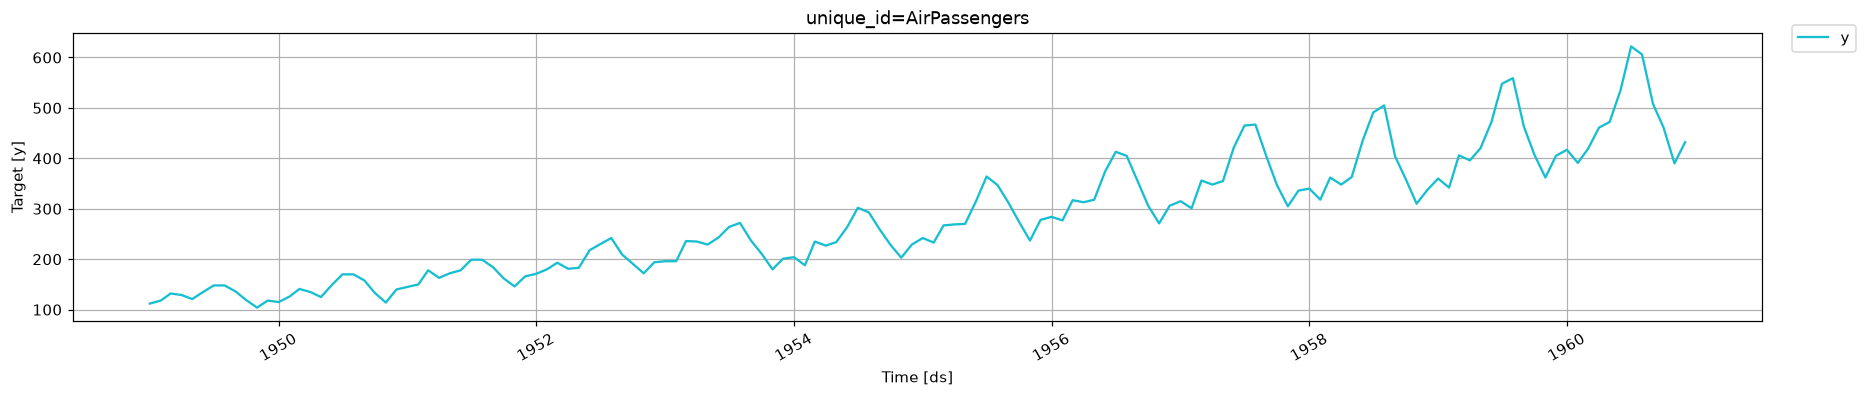

In [20]:
plot_series(air)

Интереснее многорядный случай. Что делать, если рядов 25, а на экран влезает 8?
Здесь работает механизм отбора, о котором важно знать заранее.

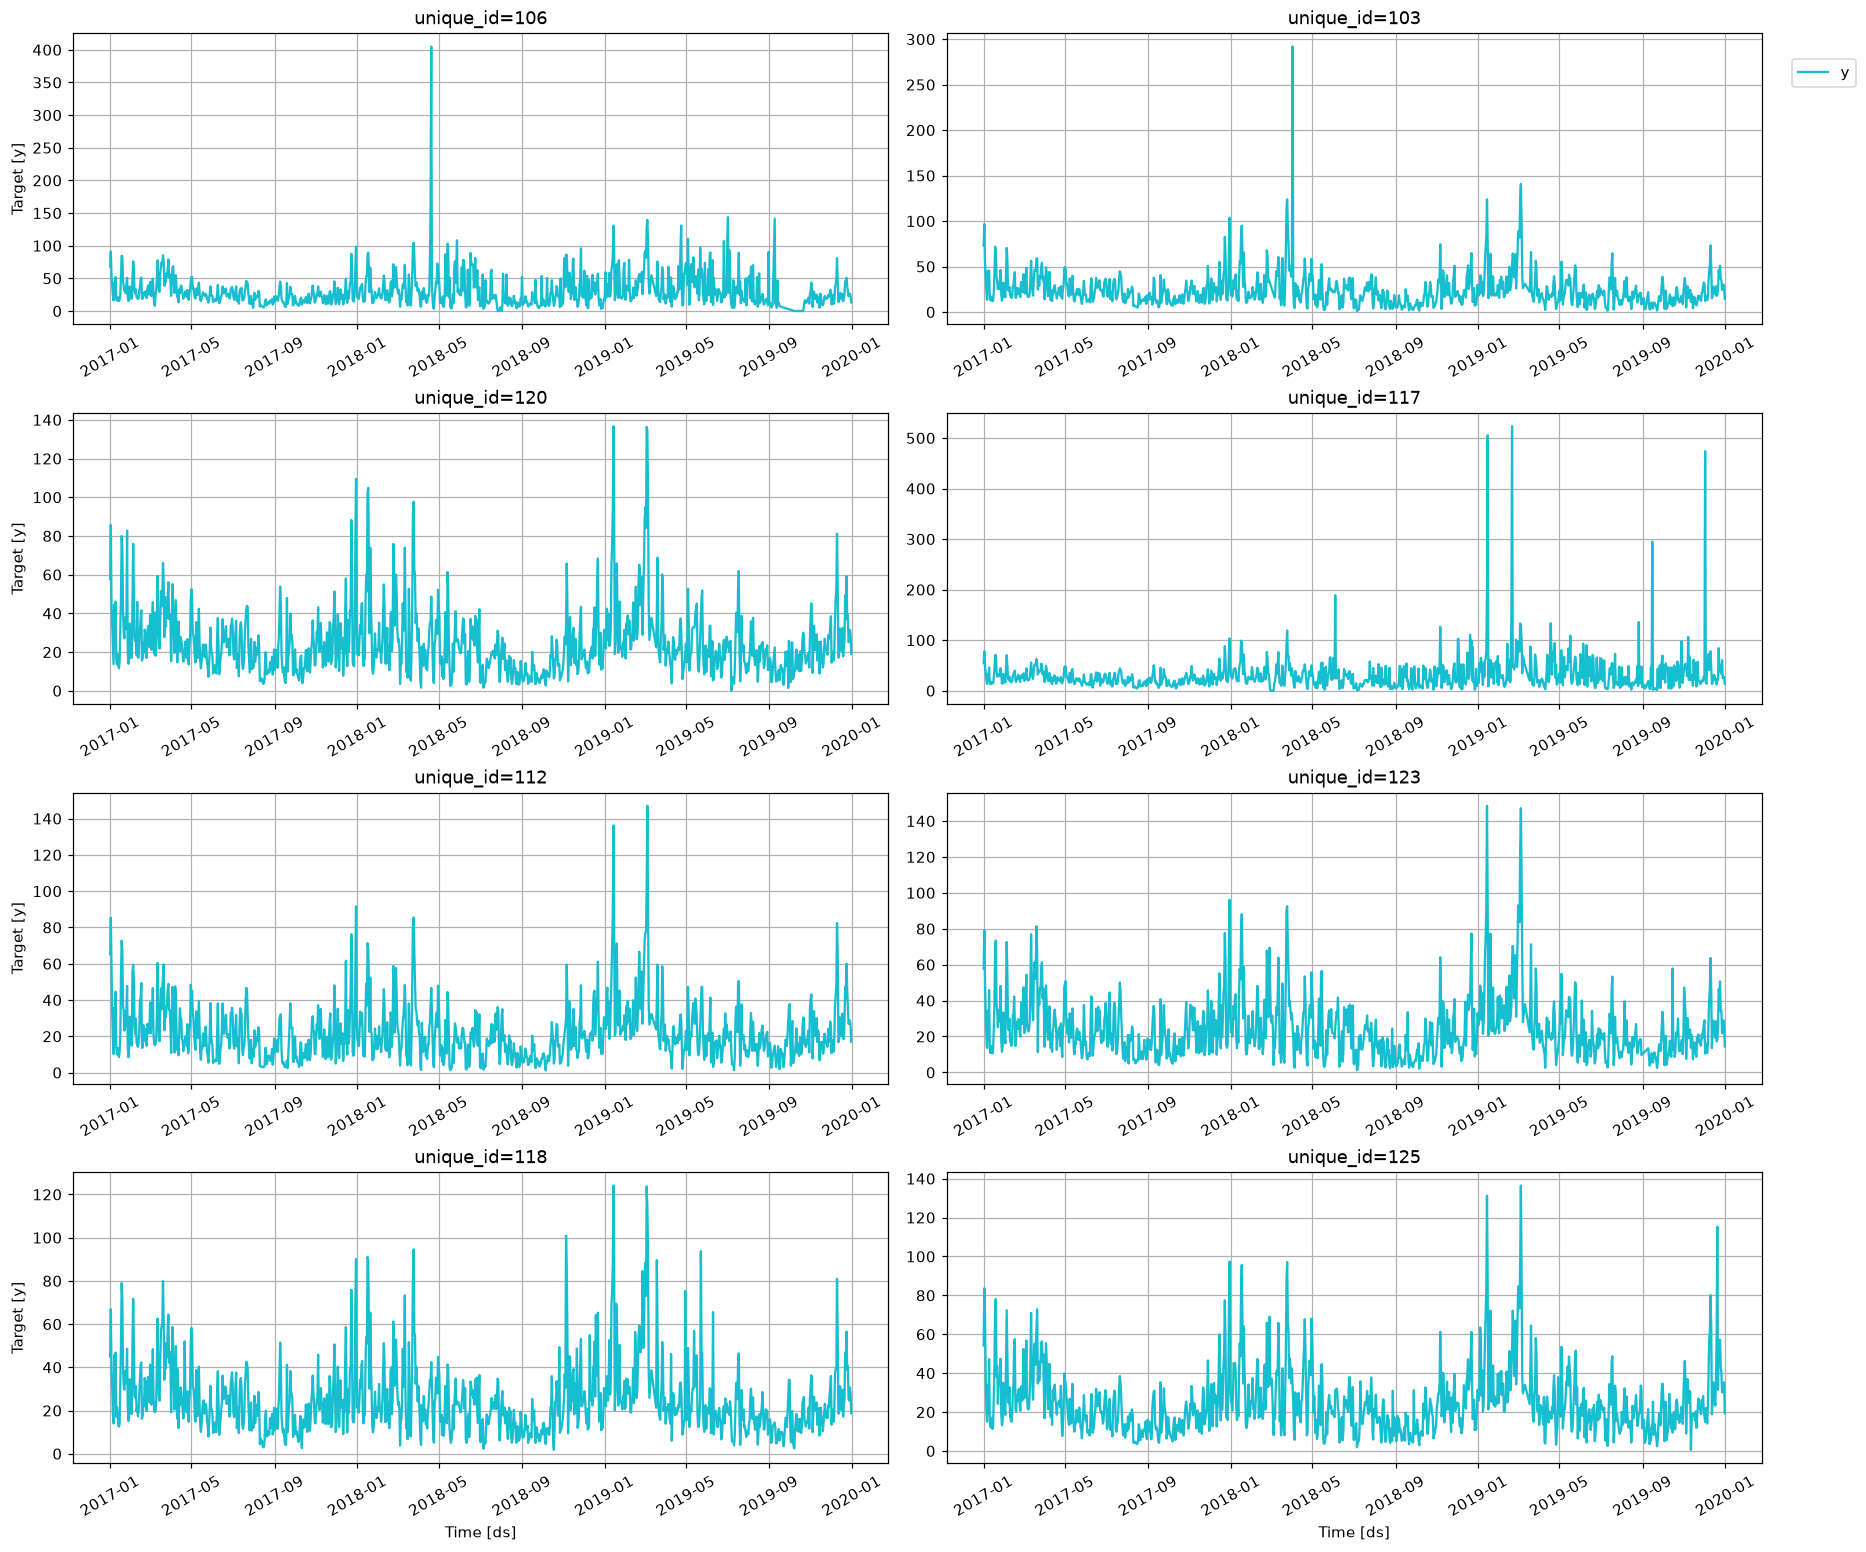

In [21]:
# По умолчанию: max_ids=8, plot_random=True -> 8 СЛУЧАЙНЫХ рядов.
plot_series(aq, max_ids=8)

🔍 Важная деталь: по умолчанию `plot_random=True`, то есть библиотека показывает
**случайную** выборку рядов, а не первые восемь. Это сделано намеренно — первые
по алфавиту ряды обычно ничем не примечательны, а случайная выборка честнее
представляет всю совокупность.

Побочный эффект: график может меняться между запусками. Есть три способа управлять этим.

Смотрим станции: ['121', '106', '105']


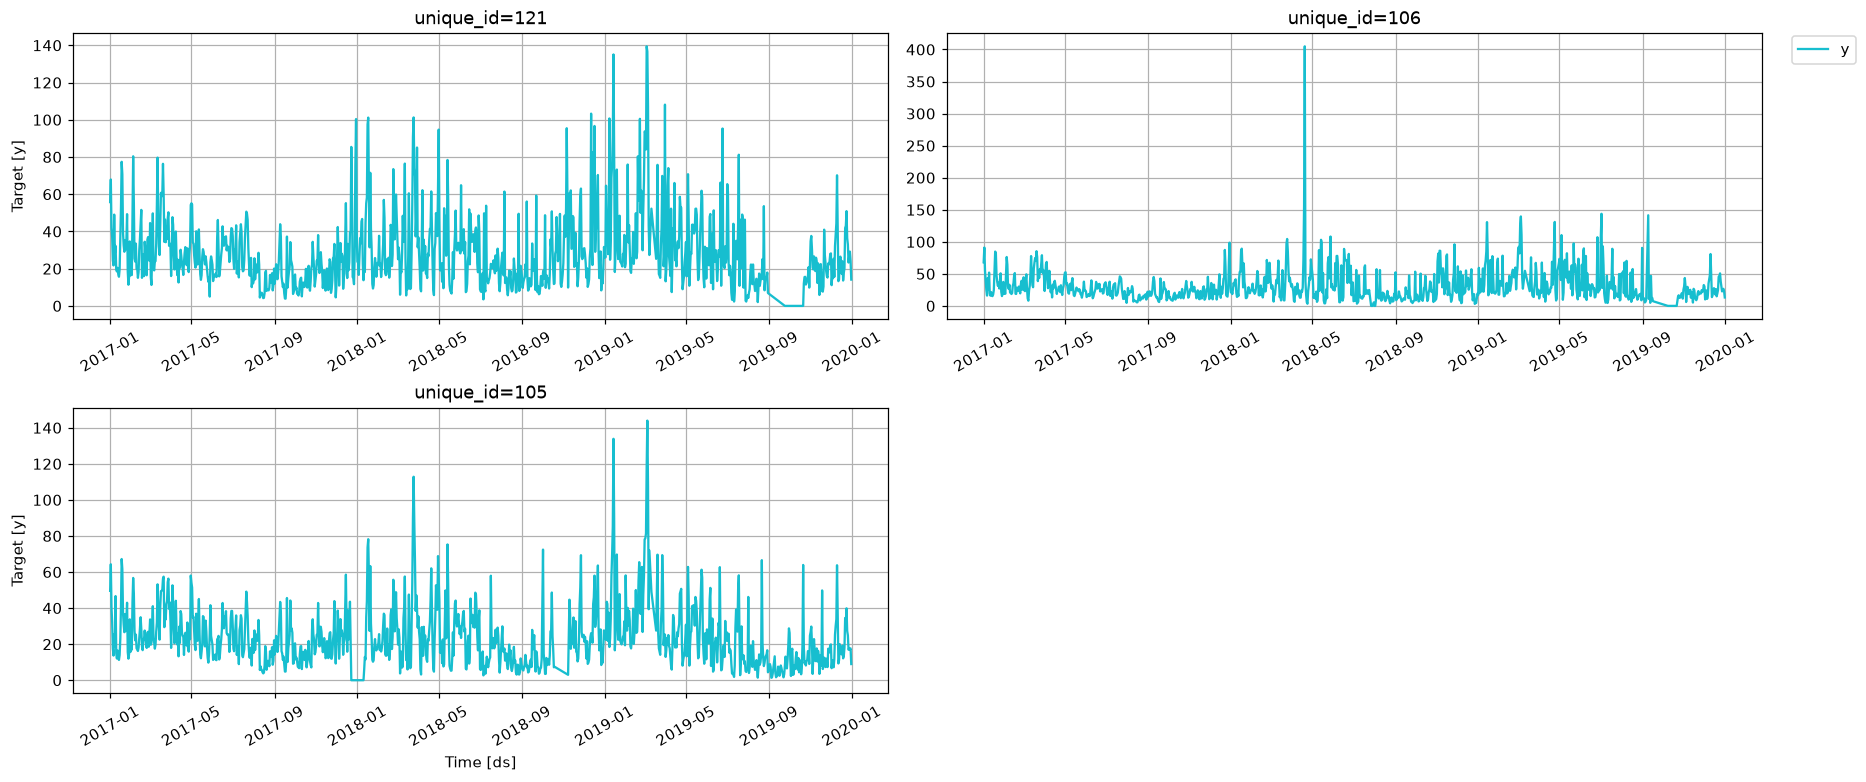

In [22]:
# Способ 1: конкретные ряды по идентификаторам — когда точно знаете, что смотреть.
# Возьмём станции с наибольшим числом сломанных замеров из раздела 1.6.
problem_stations = (
    broken.groupby("unique_id").size().sort_values(ascending=False).head(3).index.tolist()
)
print("Смотрим станции:", problem_stations)

plot_series(aq, ids=problem_stations)

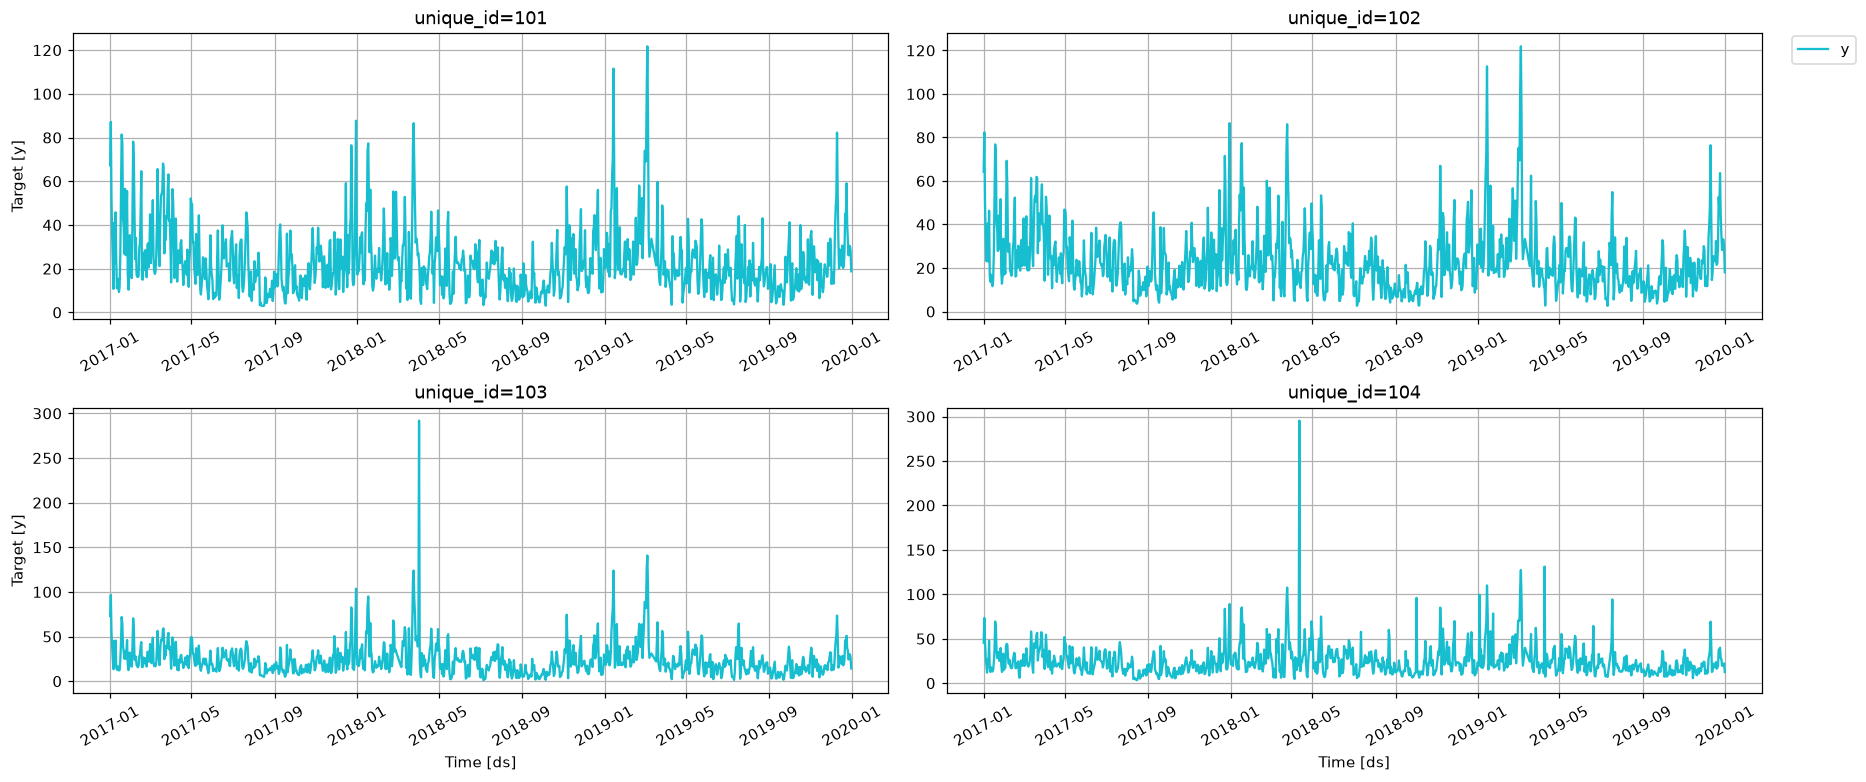

In [23]:
# Способ 2: plot_random=False -> первые max_ids рядов, порядок стабилен.
plot_series(aq, ids=None, max_ids=4, plot_random=False)

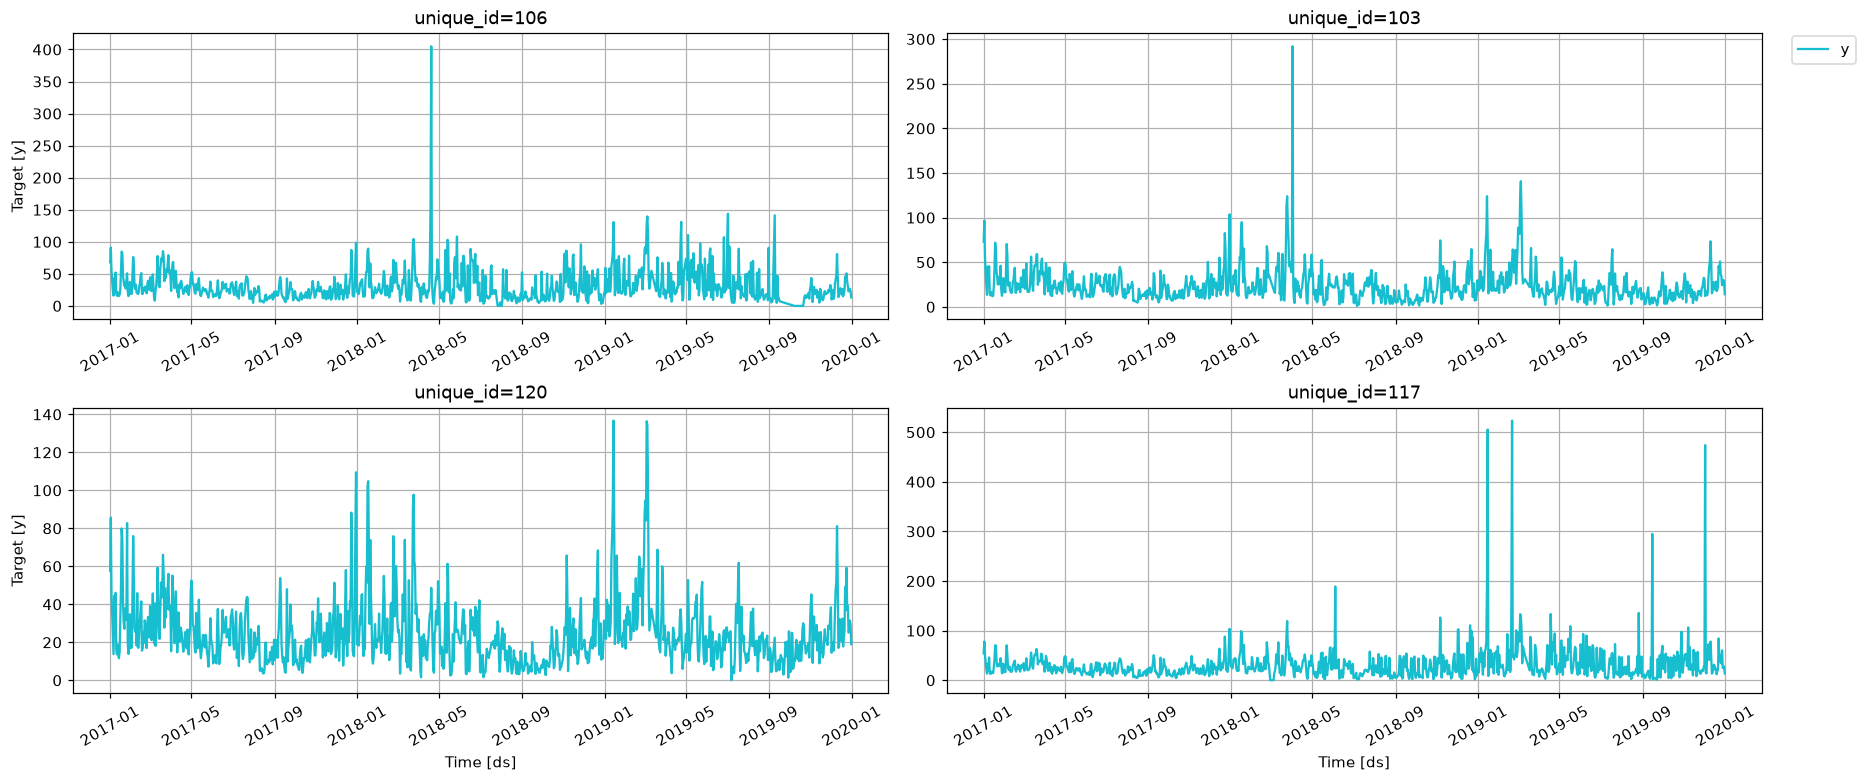

In [24]:
# Способ 3: seed фиксирует случайную выборку — воспроизводимо и по-прежнему случайно.
plot_series(aq, max_ids=4, seed=0)

## 2.2. Интерактивные графики: `engine='plotly'`

По умолчанию `plot_series` рисует через `matplotlib` и возвращает объект `Figure`.
Аргумент `engine='plotly'` даёт интерактивную версию: масштабирование колесом,
всплывающие подсказки со значениями, включение и выключение линий по клику
на легенду.

Для 25 станций за три года это заметно удобнее статичной картинки.

In [25]:
plot_series(
    aq,
    ids=problem_stations,
    engine="plotly",
)

🔍 `plot_series` **возвращает** объект фигуры, а не только рисует его. Это значит,
что график можно доработать обычными средствами `matplotlib` — например, добавить
заголовок или вертикальную линию.

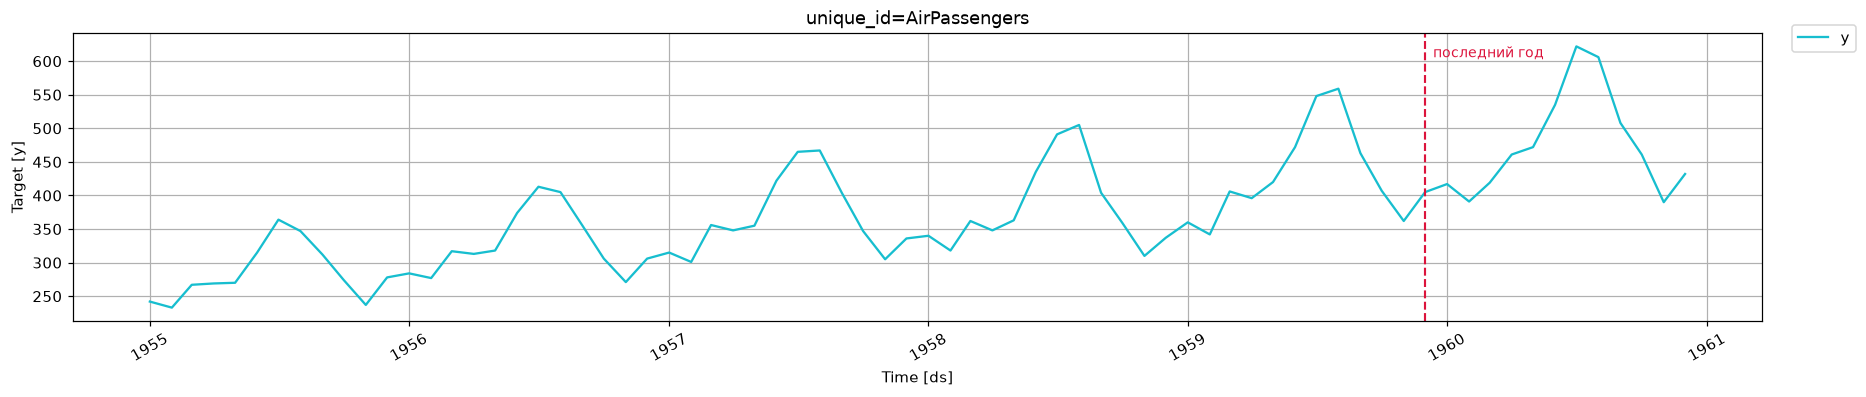

In [26]:
fig = plot_series(air, max_insample_length=72)

# Отметим на графике начало последнего года истории.
ax = fig.axes[0]
mark = air["ds"].max() - pd.DateOffset(months=12)
ax.axvline(mark, color="crimson", linestyle="--", linewidth=1.4)
ax.text(mark, ax.get_ylim()[1] * 0.97, "  последний год",
        color="crimson", fontsize=9, va="top")
fig

## 2.3. Чего в `plot_series` нет — и как это получить

Раз функция одна, полезно сразу знать её границы. Коррелограммы, сезонных графиков
и диагностики остатков здесь нет. Их берут из `statsmodels`, вытащив один ряд
из длинной таблицы.

Мостик между форматами — две строки кода, и его стоит запомнить.

Тип: Series
freq индекса: <MonthBegin>


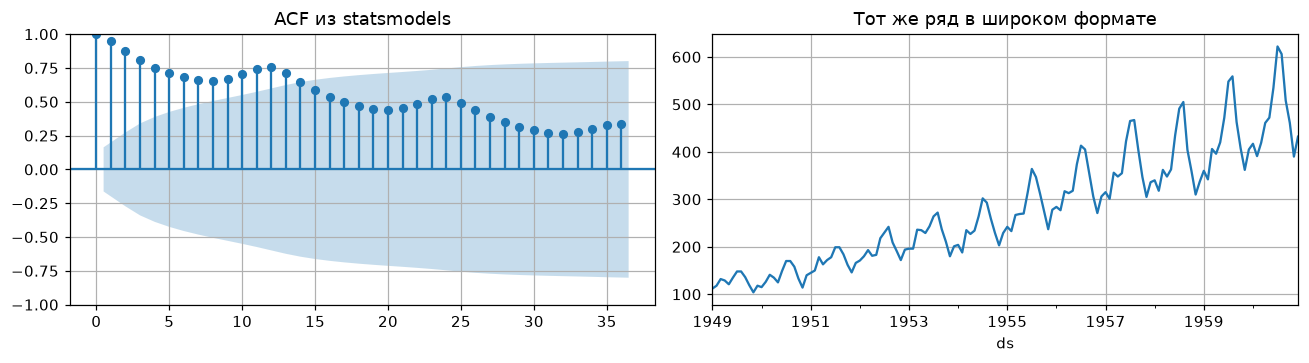

In [27]:
from statsmodels.graphics.tsaplots import plot_acf

# ДЛИННЫЙ ФОРМАТ -> WIDE: выбираем ряд, ds делаем индексом, задаём freq.
one_series = (
    air.set_index("ds")["y"]   # DataFrame -> Series с DatetimeIndex
    .asfreq("MS")              # объявляем частоту: этого требует statsmodels
)

print("Тип:", type(one_series).__name__)
print("freq индекса:", one_series.index.freq)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
plot_acf(one_series, lags=36, ax=axes[0])
axes[0].set_title("ACF из statsmodels")
one_series.plot(ax=axes[1], title="Тот же ряд в широком формате")
plt.tight_layout()
plt.show()

🔍 Вот и ответ на вопрос «какой библиотекой пользоваться». Формат данных — не
идеология, а инструмент. Длинный удобен для массового прогнозирования, широкий —
для анализа одного ряда. Переход между ними стоит одну строку, и хороший рабочий
процесс пользуется обоими.

---
# Итоги

## Что важно запомнить

**0. Концепция.** `StatsForecast` создан для прогнозирования **множества рядов**.
Отсюда всё остальное: длинный формат данных, частота как свойство задачи,
`Auto`-модели без ручной настройки. Библиотека состоит из трёх пакетов, и графика
живёт в `utilsforecast.plotting` — не в `statsforecast`.

**1. Формат данных.** Обычный `DataFrame` с тремя столбцами: `unique_id`, `ds`, `y`.
Даты — в **столбце**, а не в индексе. `freq` задаётся при создании
`StatsForecast(models=..., freq=...)`. Ряды могут быть разной длины — это норма.

| Цель | Инструмент | Пакет |
|---|---|---|
| проверить формат | `validate_format` | `utilsforecast.validation` |
| найти дыры в календаре | `fill_gaps` | `utilsforecast.preprocessing` |
| получить тестовые данные | `AirPassengersDF`, `generate_series` | `statsforecast.utils` |

Обе функции работы с данными принимают таблицу целиком и действуют внутри
каждого `unique_id` — циклы по рядам не нужны.

**2. Визуализация.** Одна функция `plot_series` вместо набора графиков.
Аргументы, которые мы разобрали:

| Аргумент | Зачем |
|---|---|
| `ids`, `max_ids`, `plot_random`, `seed` | выбрать, какие ряды показать |
| `max_insample_length` | обрезать историю |
| `engine='plotly'` | интерактивная версия |

🔍 У `plot_series` есть ещё группа аргументов — `forecasts_df`, `models`, `level`,
`plot_anomalies`. Все они про **прогнозы**, которых у нас сегодня не было. Разберём
их на занятии про оценку качества: там же станет понятно соглашение об именах
столбцов вида `Модель-lo-95` / `Модель-hi-95`.

## Место `StatsForecast` среди других библиотек

| Библиотека | Формат данных | Сильная сторона |
|---|---|---|
| **statsmodels** | `pd.Series` / `pd.DataFrame` + `freq` | статистика, тесты, диагностика, интерпретируемость |
| **StatsForecast** | длинный: `unique_id`, `ds`, `y` | скорость на тысячах рядов, `Auto`-модели |
| **sktime** | `pd.DataFrame` с MultiIndex | единый API в стиле `scikit-learn`, пайплайны |
| **ETNA** | свой `TSDataset` | промышленные пайплайны, работа с множеством рядов |
| **Darts** | свой `TimeSeries` | нейросетевые модели |

Практический вывод для курса: `statsmodels` отвечает на вопрос **«что происходит
в этом ряде?»**, `StatsForecast` — на вопрос **«как быстро построить приличный
прогноз для всех рядов сразу?»**. Это разные вопросы, и хороший аналитик задаёт оба.

## Что дальше

Сегодня мы научились приводить данные к формату Nixtla, проверять их на дыры
и смотреть на них. Следующие шаги — на отдельных занятиях:

* **преобразования данных** — признаки Фурье, календарные атрибуты, Box–Cox,
  скейлеры для каждого ряда;
* **прогнозы и их анализ** — `forecast`, доверительные интервалы, поиск аномалий,
  кросс-валидация и метрики.

---
# Задания для самостоятельной работы

Данные лежат в папке [examples_data](https://github.com/alex-hse-repository/time-series-cu-2026/tree/main/examples_data). Для каждого задания есть подсказка о том,
какой инструмент из ноутбука пригодится.

**Задание 1 (формат данных).** Загрузите `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/monthly-car-sales.csv`.
Даты записаны как `1960-01` — проверьте, справляется ли `parse_dates`, и посмотрите
на `df.dtypes`. Приведите таблицу к длинному формату (`unique_id`, `ds`, `y`)
и убедитесь через `validate_format`, что всё корректно. Какое значение `freq`
нужно передать в `StatsForecast` для этих данных — `'MS'` или `'ME'`?

**Задание 2 (гигиена данных).** Загрузите `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/daily-total-female-births.csv`
(дневные данные, столбец с датой — `Date`). Приведите к длинному формату и примените
`fill_gaps(freq='D')`. Есть ли пропущенные дни? Затем **испортите** данные
самостоятельно: удалите 10 случайных строк через `df.drop(...)` и проверьте,
что `fill_gaps` их находит.

**Задание 3 (несколько рядов в одной таблице).** Из датасета качества воздуха
возьмите **три разных загрязнителя** (`PM10`, `NO2`, `O3`) для **одной** станции.
Соберите их в одну длинную таблицу, где `unique_id` — название загрязнителя.
Постройте `plot_series`. Подсказка: чтобы получить длинный формат из широкого,
удобна `pd.melt`. Не забудьте про sentinel-значения `-1`.

**Задание 4 (отбор рядов).** Постройте `plot_series` для датасета качества воздуха
так, чтобы на экране оказались **ровно те четыре станции**, у которых больше всего
сломанных замеров. Затем добейтесь, чтобы при повторном запуске ячейки картинка
не менялась, — двумя разными способами.

**Задание 5 (мостик между библиотеками).** Возьмите одну станцию из датасета
качества воздуха, переведите её ряд в широкий формат (`set_index` + `asfreq`)
и постройте `plot_acf` с `lags=30`. Видна ли недельная сезонность (пики на лагах
7, 14, 21)? Ответ «сезонности нет» — такой же полноценный результат, как и
«сезонность есть»; обоснуйте его границами значимости на графике.

**Задание 6\* (обратный мостик).** Задание 5 переводило один ряд из длинного формата
в широкий. Сделайте обратное: возьмите **широкую** таблицу качества воздуха
(даты в индексе, 25 станций в столбцах) и приведите её к длинному формату Nixtla.
Подсказка: `pd.melt` или `.stack()`. Проверьте результат через `validate_format`.

**Задание 7\* (свои имена столбцов).** В разделе 1.1 упоминалось, что имена
`unique_id`, `ds`, `y` — лишь значения по умолчанию. Постройте `plot_series` для
таблицы, где столбцы названы `станция`, `дата`, `pm25`, **не переименовывая их**.
Подсказка: аргументы `id_col`, `time_col`, `target_col`.